In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional aesthetic for your plots
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load Data
df = pd.read_csv('../data/application_train.csv')

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (307511, 122)


In [5]:
import pandas as pd
import numpy as np

# Assuming 'df' is your original loaded dataset
excluded_normalized_features = []

# Iterate through all columns
for col in df.columns:
    # Skip the ID and TARGET columns so we don't accidentally process them
    if col in ['SK_ID_CURR', 'TARGET']:
        continue
        
    # Check if the column type is a float (algorithms generate floats, user inputs are usually ints or text)
    if pd.api.types.is_float_dtype(df[col]):
        # Get min and max, automatically ignoring NaNs
        min_val = df[col].min()
        max_val = df[col].max()
        
        # Rule: Exclude if the float values strictly fall between 0.0 and 1.0
        if min_val >= 0.0 and max_val <= 1.0:
            excluded_normalized_features.append(col)

# Save the remaining raw features in a new variable (excluding ID and TARGET)
remaining_features_pool = [col for col in df.columns 
                           if col not in excluded_normalized_features 
                           and col not in ['SK_ID_CURR', 'TARGET']]

# Print the results matching your format
print("Features excluded in this round [Calculated floats 0-1]:\n")
print(f"[{', '.join(excluded_normalized_features)}]")

print(f"\nTotal excluded features: {len(excluded_normalized_features)}")
print(f"Total remaining usable features: {len(remaining_features_pool)}")
print(f"[{', '.join(remaining_features_pool)}]")


Features excluded in this round [Calculated floats 0-1]:

[REGION_POPULATION_RELATIVE, EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3, APARTMENTS_AVG, BASEMENTAREA_AVG, YEARS_BEGINEXPLUATATION_AVG, YEARS_BUILD_AVG, COMMONAREA_AVG, ELEVATORS_AVG, ENTRANCES_AVG, FLOORSMAX_AVG, FLOORSMIN_AVG, LANDAREA_AVG, LIVINGAPARTMENTS_AVG, LIVINGAREA_AVG, NONLIVINGAPARTMENTS_AVG, NONLIVINGAREA_AVG, APARTMENTS_MODE, BASEMENTAREA_MODE, YEARS_BEGINEXPLUATATION_MODE, YEARS_BUILD_MODE, COMMONAREA_MODE, ELEVATORS_MODE, ENTRANCES_MODE, FLOORSMAX_MODE, FLOORSMIN_MODE, LANDAREA_MODE, LIVINGAPARTMENTS_MODE, LIVINGAREA_MODE, NONLIVINGAPARTMENTS_MODE, NONLIVINGAREA_MODE, APARTMENTS_MEDI, BASEMENTAREA_MEDI, YEARS_BEGINEXPLUATATION_MEDI, YEARS_BUILD_MEDI, COMMONAREA_MEDI, ELEVATORS_MEDI, ENTRANCES_MEDI, FLOORSMAX_MEDI, FLOORSMIN_MEDI, LANDAREA_MEDI, LIVINGAPARTMENTS_MEDI, LIVINGAREA_MEDI, NONLIVINGAPARTMENTS_MEDI, NONLIVINGAREA_MEDI, TOTALAREA_MODE]

Total excluded features: 47
Total remaining usable features: 73
[NAME_

In [6]:
# Cell 3: Exclude External Bureau and Bank-Verified Document Features

# 1. Define the prefixes of features that represent external bank/bureau processes
external_prefixes = ('FLAG_DOCUMENT_', 'AMT_REQ_CREDIT_BUREAU_')

# 2. Find features in the current pool that start with these prefixes
excluded_external_features = [col for col in remaining_features_pool if col.startswith(external_prefixes)]

# 3. Update the pool by removing the excluded features
remaining_features_pool = [col for col in remaining_features_pool if col not in excluded_external_features]

# 4. Print the results
print("Features excluded in this round [External Bureau & Bank Documents]:\n")
print(f"[{', '.join(excluded_external_features)}]")

print(f"\nTotal excluded in this round: {len(excluded_external_features)}")
print(f"Total remaining usable features: {len(remaining_features_pool)}")
print(f"[{', '.join(remaining_features_pool)}]")

Features excluded in this round [External Bureau & Bank Documents]:

[FLAG_DOCUMENT_2, FLAG_DOCUMENT_3, FLAG_DOCUMENT_4, FLAG_DOCUMENT_5, FLAG_DOCUMENT_6, FLAG_DOCUMENT_7, FLAG_DOCUMENT_8, FLAG_DOCUMENT_9, FLAG_DOCUMENT_10, FLAG_DOCUMENT_11, FLAG_DOCUMENT_12, FLAG_DOCUMENT_13, FLAG_DOCUMENT_14, FLAG_DOCUMENT_15, FLAG_DOCUMENT_16, FLAG_DOCUMENT_17, FLAG_DOCUMENT_18, FLAG_DOCUMENT_19, FLAG_DOCUMENT_20, FLAG_DOCUMENT_21, AMT_REQ_CREDIT_BUREAU_HOUR, AMT_REQ_CREDIT_BUREAU_DAY, AMT_REQ_CREDIT_BUREAU_WEEK, AMT_REQ_CREDIT_BUREAU_MON, AMT_REQ_CREDIT_BUREAU_QRT, AMT_REQ_CREDIT_BUREAU_YEAR]

Total excluded in this round: 26
Total remaining usable features: 47
[NAME_CONTRACT_TYPE, CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, CNT_CHILDREN, AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE, NAME_TYPE_SUITE, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_ID_PUBLISH, OWN_CAR_AGE, FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_

47 features Left

Features that can be exclude next:

DAYS_REGISTRATION	 (Either register to the Loan or register to the system, it is useless(since our project no need user registration))
DAYS_ID_PUBLISH	     (Either User ID or IC ID , it is useless)

REGION_RATING_CLIENT	                (algorithms related)
REGION_RATING_CLIENT_W_CITY	            (algorithms related)

WEEKDAY_APPR_PROCESS_START	            (the project not register to a Loan, only credit scoring)
HOUR_APPR_PROCESS_START	                (the project not register to a Loan, only credit scoring)

NAME_TYPE_SUITE	                        (self submit project)


Features that might can be combine (cause similar, thus, may EDA):

Location Related:
REG_REGION_NOT_LIVE_REGION	        
REG_REGION_NOT_WORK_REGION	        
LIVE_REGION_NOT_WORK_REGION	        
REG_CITY_NOT_LIVE_CITY	            
REG_CITY_NOT_WORK_CITY	            
LIVE_CITY_NOT_WORK_CITY	            

Social Circle Related:
OBS_30_CNT_SOCIAL_CIRCLE	
DEF_30_CNT_SOCIAL_CIRCLE	
OBS_60_CNT_SOCIAL_CIRCLE	
DEF_60_CNT_SOCIAL_CIRCLE	

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Execute Exclusion of Irrelevant Features

features_to_drop = [
    'DAYS_REGISTRATION',            # Either register to Loan or system, useless (since our project no need user registration
    'DAYS_ID_PUBLISH',              # Either User ID or IC ID publish date, useless (since our project no need user registration)
    'REGION_RATING_CLIENT',         # algorithms related
    'REGION_RATING_CLIENT_W_CITY',  # algorithms related
    'WEEKDAY_APPR_PROCESS_START',   # the project not register to a Loan, only credit scoring
    'HOUR_APPR_PROCESS_START',      # the project not register to a Loan, only credit scoring
    'NAME_TYPE_SUITE'               # self submit project, useless
]

# Exclude these features from our working pool
remaining_features_pool = [col for col in remaining_features_pool if col not in features_to_drop]

print("--- Exclusion Execution ---")
print("Features excluded in this round [Irrelevant Context / Algorithmic]:")
print(f"[{', '.join(features_to_drop)}]")

print(f"\nTotal excluded in this round: {len(features_to_drop)}")
print(f"Total remaining usable features: {len(remaining_features_pool)}")
print(f"\nRemaining Features Pool:\n[{', '.join(remaining_features_pool)}]")

--- Exclusion Execution ---
Features excluded in this round [Irrelevant Context / Algorithmic]:
[DAYS_REGISTRATION, DAYS_ID_PUBLISH, REGION_RATING_CLIENT, REGION_RATING_CLIENT_W_CITY, WEEKDAY_APPR_PROCESS_START, HOUR_APPR_PROCESS_START, NAME_TYPE_SUITE]

Total excluded in this round: 7
Total remaining usable features: 40

Remaining Features Pool:
[NAME_CONTRACT_TYPE, CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, CNT_CHILDREN, AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, DAYS_BIRTH, DAYS_EMPLOYED, OWN_CAR_AGE, FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_WORK_PHONE, FLAG_CONT_MOBILE, FLAG_PHONE, FLAG_EMAIL, OCCUPATION_TYPE, CNT_FAM_MEMBERS, REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, LIVE_REGION_NOT_WORK_REGION, REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY, ORGANIZATION_TYPE, FONDKAPREMONT_MODE, HOUSETYPE_MODE, WALLSMATERIAL_MODE, EMERGENCYSTATE_MODE, OBS_30_CNT_SOCIAL_C

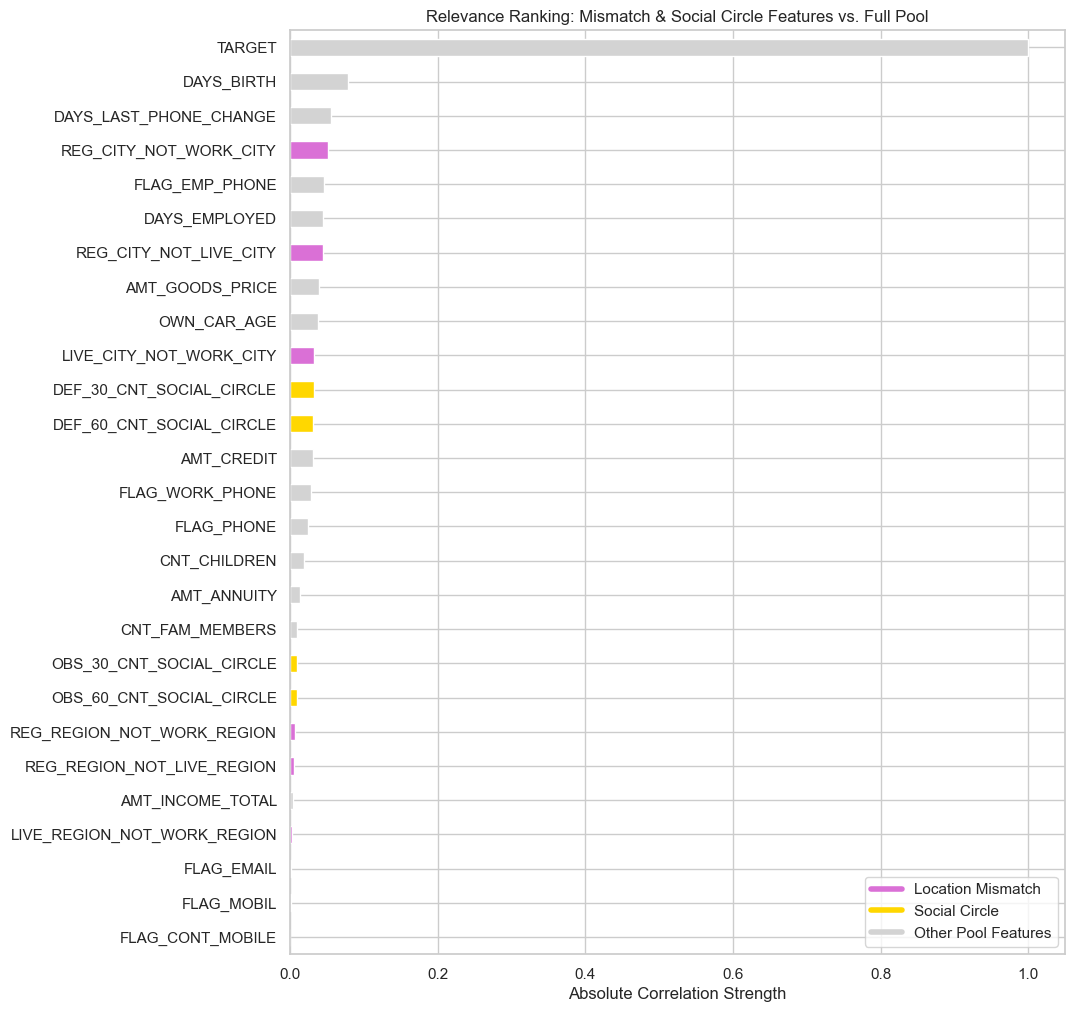

--- Internal Correlation Check (Redundancy) ---

Social Circle Internal Correlation:
                          OBS_30_CNT_SOCIAL_CIRCLE  DEF_30_CNT_SOCIAL_CIRCLE  \
OBS_30_CNT_SOCIAL_CIRCLE                  1.000000                  0.329338   
DEF_30_CNT_SOCIAL_CIRCLE                  0.329338                  1.000000   
OBS_60_CNT_SOCIAL_CIRCLE                  0.998490                  0.331571   
DEF_60_CNT_SOCIAL_CIRCLE                  0.253499                  0.860517   

                          OBS_60_CNT_SOCIAL_CIRCLE  DEF_60_CNT_SOCIAL_CIRCLE  
OBS_30_CNT_SOCIAL_CIRCLE                  0.998490                  0.253499  
DEF_30_CNT_SOCIAL_CIRCLE                  0.331571                  0.860517  
OBS_60_CNT_SOCIAL_CIRCLE                  1.000000                  0.255570  
DEF_60_CNT_SOCIAL_CIRCLE                  0.255570                  1.000000  

Location Mismatch Internal Correlation :
                         REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY
REG_

In [11]:
# Cell: Investigate Redundancy and Relevance of Targeted 10 Features

# 1. Define the groups for investigation
mismatch_features = [
    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY'
]
social_circle_features = [
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'
]
targeted_investigation = mismatch_features + social_circle_features

# 2. Calculate Absolute Correlation for the entire 40-feature pool
# Note: Categorical strings will be skipped automatically with numeric_only=True
full_pool_corr = df[remaining_features_pool + ['TARGET']].corr(numeric_only=True)['TARGET'].abs().sort_values()

# 3. Visualization
plt.figure(figsize=(10, 12))

# Highlight the targeted 10 features in different colors to see their relative rank
colors = []
for feat in full_pool_corr.index:
    if feat in mismatch_features:
        colors.append('orchid') # Purple for Location Mismatches
    elif feat in social_circle_features:
        colors.append('gold')   # Yellow for Social Circle
    else:
        colors.append('lightgrey')

full_pool_corr.plot(kind='barh', color=colors)
plt.title('Relevance Ranking: Mismatch & Social Circle Features vs. Full Pool')
plt.xlabel('Absolute Correlation Strength')

# Add legend for clarity
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orchid', lw=4, label='Location Mismatch'),
    Line2D([0], [0], color='gold', lw=4, label='Social Circle'),
    Line2D([0], [0], color='lightgrey', lw=4, label='Other Pool Features')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.show()

# 4. Check Internal Redundancy (Multicollinearity)
print("--- Internal Correlation Check (Redundancy) ---")
print("\nSocial Circle Internal Correlation:")
print(df[social_circle_features].corr())

print("\nLocation Mismatch Internal Correlation :")
print(df[['REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']].corr())

OBS_30_CNT_SOCIAL_CIRCLE AND OBS_60_CNT_SOCIAL_CIRCLE       0.998490
Highly Correlation, thus, they might be redundancy. According relevance ranking, OBS_30_CNT_SOCIAL_CIRCLE will be taken. 

DEF_30_CNT_SOCIAL_CIRCLE AND DEF_60_CNT_SOCIAL_CIRCLE       0.860517
High Correlation, but unaffected Tree Model (LightGBM). Thus, can be reserved

For Location Mismatch, All features be reserved

In [12]:
# Cell: Final Exclusion and Lock Final Feature Pool

# 1. Define the redundant feature identified in EDA
redundant_social_feature = ['OBS_60_CNT_SOCIAL_CIRCLE']

# 2. Update the pool by removing the redundant feature
remaining_features_pool = [col for col in remaining_features_pool if col not in redundant_social_feature]

print("--- Final Feature Selection Complete ---")
print(f"Excluded in this round: {redundant_social_feature}")
print(f"Total Final Usable Features: {len(remaining_features_pool)}")

# 3. Display the final list alphabetically for easy review
final_features = sorted(remaining_features_pool)
print("\nFinal Feature Pool for Model Rebuild:")
print(f"[{', '.join(final_features)}]")

--- Final Feature Selection Complete ---
Excluded in this round: ['OBS_60_CNT_SOCIAL_CIRCLE']
Total Final Usable Features: 39

Final Feature Pool for Model Rebuild:
[AMT_ANNUITY, AMT_CREDIT, AMT_GOODS_PRICE, AMT_INCOME_TOTAL, CNT_CHILDREN, CNT_FAM_MEMBERS, CODE_GENDER, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_LAST_PHONE_CHANGE, DEF_30_CNT_SOCIAL_CIRCLE, DEF_60_CNT_SOCIAL_CIRCLE, EMERGENCYSTATE_MODE, FLAG_CONT_MOBILE, FLAG_EMAIL, FLAG_EMP_PHONE, FLAG_MOBIL, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_PHONE, FLAG_WORK_PHONE, FONDKAPREMONT_MODE, HOUSETYPE_MODE, LIVE_CITY_NOT_WORK_CITY, LIVE_REGION_NOT_WORK_REGION, NAME_CONTRACT_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE, NAME_INCOME_TYPE, OBS_30_CNT_SOCIAL_CIRCLE, OCCUPATION_TYPE, ORGANIZATION_TYPE, OWN_CAR_AGE, REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, REG_REGION_NOT_LIVE_REGION, REG_REGION_NOT_WORK_REGION, WALLSMATERIAL_MODE]


In [13]:
import json

# 1. Final exclusion of the redundant social circle feature
features_to_drop_final = ['OBS_60_CNT_SOCIAL_CIRCLE']
remaining_features_pool = [col for col in remaining_features_pool if col not in features_to_drop_final]

# 2. Final Check
print("--- Final Feature Selection Complete ---")
print(f"Excluded in this round: {features_to_drop_final}")
print(f"Total Final Usable Features: {len(remaining_features_pool)}")

# 3. Save the list to a JSON file for the next notebook
config = {
    "final_features": remaining_features_pool,
    "target": "TARGET",
    "id": "SK_ID_CURR"
}

with open('final_features_config.json', 'w') as f:
    json.dump(config, f)

print("\nSuccess! Final feature list saved to 'final_features_config.json'.")

--- Final Feature Selection Complete ---
Excluded in this round: ['OBS_60_CNT_SOCIAL_CIRCLE']
Total Final Usable Features: 39

Success! Final feature list saved to 'final_features_config.json'.
